# Work01：使用 CLIP 做狗图像的 Zero-Shot 识别

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import ChineseCLIPModel, ChineseCLIPProcessor

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

ChineseCLIPModel LOAD REPORT from: e:\八斗视频\预习\第10周：多模态大模型\Week10\model\chinese-clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cuda


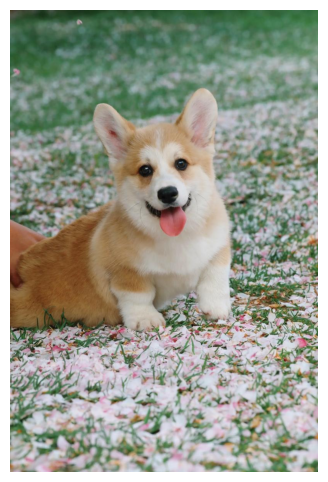

In [2]:
base_dir = Path.cwd()
image_path = base_dir / "dog.jpg"
model_path = base_dir / "model" / "chinese-clip-vit-base-patch16"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ChineseCLIPModel.from_pretrained(model_path, local_files_only=True).to(device)
model.eval()
processor = ChineseCLIPProcessor.from_pretrained(model_path, local_files_only=True)

image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
print(f"device: {device}")

In [3]:
candidate_labels = ["狗", "猫", "狼", "狐狸", "兔子", "熊"]
prompt_templates = [
    "这是一只{}",
    "一张{}的照片",
    "图片里是一只{}"
]

texts = [template.format(label) for label in candidate_labels for template in prompt_templates]
texts[:6]

['这是一只狗', '一张狗的照片', '图片里是一只狗', '这是一只猫', '一张猫的照片', '图片里是一只猫']

In [4]:
inputs = processor(images=image, text=texts, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits_per_image.view(len(candidate_labels), len(prompt_templates))
    logits = logits.mean(dim=1)
    probs = logits.softmax(dim=0).detach().cpu().numpy()

label_probs = sorted(zip(candidate_labels, probs.tolist()), key=lambda x: x[1], reverse=True)
pred_label, pred_prob = label_probs[0]

print("预测结果:", pred_label)
print("置信度:", f"{pred_prob:.4f}")
label_probs

预测结果: 狗
置信度: 0.8652


[('狗', 0.8652139902114868),
 ('狐狸', 0.06046365201473236),
 ('兔子', 0.05391634628176689),
 ('猫', 0.009252050891518593),
 ('熊', 0.00592466676607728),
 ('狼', 0.0052292379550635815)]

c:\ProgramData\anaconda3\envs\ai_study\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29399 (\N{CJK UNIFIED IDEOGRAPH-72D7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\ai_study\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29392 (\N{CJK UNIFIED IDEOGRAPH-72D0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\ai_study\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29432 (\N{CJK UNIFIED IDEOGRAPH-72F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\ai_study\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20820 (\N{CJK UNIFIED IDEOGRAPH-5154}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\envs\ai_study\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

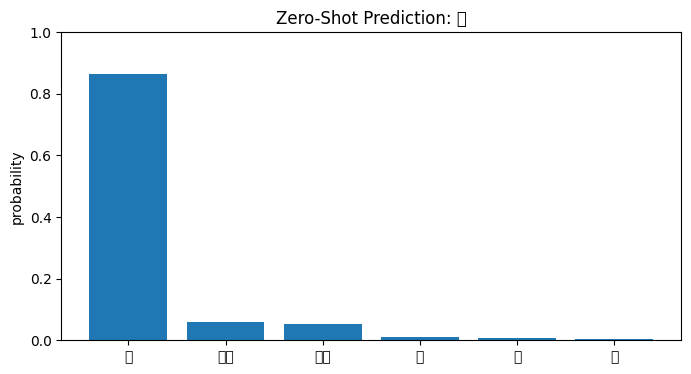

In [5]:
labels = [item[0] for item in label_probs]
scores = [item[1] for item in label_probs]

plt.figure(figsize=(8, 4))
plt.bar(labels, scores)
plt.ylim(0, 1)
plt.ylabel("probability")
plt.title(f"Zero-Shot Prediction: {pred_label}")
plt.show()